In [1]:
import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import torch
import shap

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    pipeline,
)
from IPython.display import display, HTML

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        11,
})

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = "../models/distilbert-imdb"

COLOURS = {
    "positive": "#2E9E6B",
    "negative": "#E74C3C",
    "neutral":  "#AAAAAA",
}

print("✓ Imports OK")
print(f"  SHAP version       : {shap.__version__}")
print(f"  Device             : {DEVICE}")
print(f"  Model directory    : {os.path.abspath(MODEL_DIR)}")

✓ Imports OK
  SHAP version       : 0.47.2
  Device             : cpu
  Model directory    : C:\Users\USER\models\distilbert-imdb


## Load model, tokenizer, pipeline


In [2]:
print("Loading fine-tuned DistilBERT model...")

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)

model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)
model = model.to(DEVICE)
model.eval()

# Pipeline API — used for SHAP and quick inference
clf = pipeline(
    "text-classification",
    model       = model,
    tokenizer   = tokenizer,
    device      = 0 if torch.cuda.is_available() else -1,
    truncation  = True,
    max_length  = 512,
    top_k       = None,      # return scores for ALL labels
)

# Label mapping — DistilBERT uses LABEL_0 / LABEL_1
LABEL_MAP = {"LABEL_0": "NEGATIVE", "LABEL_1": "POSITIVE"}

def predict(texts):
    """Return (label, confidence) for a list of texts."""
    results = []
    for r in clf(texts):
        scores = {LABEL_MAP[item["label"]]: item["score"] for item in r}
        label  = max(scores, key=scores.get)
        conf   = scores[label]
        results.append((label, conf, scores))
    return results

# Quick sanity check
test_preds = predict([
    "An absolute masterpiece. Stunning performances.",
    "Dreadful film. Boring from start to finish.",
])
for text, (label, conf, _) in zip(
    ["Positive test", "Negative test"], test_preds
):
    print(f"  {text}: {label} ({conf*100:.1f}%)")

print("\n✓ Model loaded and producing correct predictions")

Loading fine-tuned DistilBERT model...


Device set to use cpu


  Positive test: POSITIVE (99.8%)
  Negative test: NEGATIVE (99.8%)

✓ Model loaded and producing correct predictions


## Load test predictions from notebook 03

In [3]:
test_df = pd.read_csv("../data/test_predictions.csv")

# Ensure required columns exist
required = ["text","label","sentiment","pred_label",
            "pred_sentiment","confidence","correct","word_count"]
missing  = [c for c in required if c not in test_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing} — re-run notebook 03")

print(f"✓ Loaded test predictions: {len(test_df):,} reviews")
print(f"\nColumn summary:")
for col in required:
    dtype = test_df[col].dtype
    print(f"  {col:<20} {str(dtype):<12} "
          f"sample: {test_df[col].iloc[0]!r:.40s}")

print(f"\nAccuracy on full test set: "
      f"{test_df['correct'].mean()*100:.2f}%")
print(f"Correct   : {test_df['correct'].sum():,}")
print(f"Incorrect : {(~test_df['correct']).sum():,}")

✓ Loaded test predictions: 25,000 reviews

Column summary:
  text                 object       sample: 'I love sci-fi and am willing to put up 
  label                int64        sample: np.int64(0)
  sentiment            object       sample: 'negative'
  pred_label           int64        sample: np.int64(0)
  pred_sentiment       object       sample: 'negative'
  confidence           float64      sample: np.float64(0.9987207)
  correct              bool         sample: np.True_
  word_count           int64        sample: np.int64(230)

Accuracy on full test set: 92.82%
Correct   : 23,206
Incorrect : 1,794


##  What is SHAP?

In [4]:
print("""
SHAP — SHapley Additive exPlanations
═════════════════════════════════════
SHAP assigns each input feature a value representing its
contribution to the model's prediction.

For text models, each TOKEN gets a SHAP value:
  Positive SHAP → token pushed prediction toward POSITIVE
  Negative SHAP → token pushed prediction toward NEGATIVE
  Near zero     → token had little effect

The SHAP values sum to the difference between:
  - The model's actual prediction
  - The expected prediction over all inputs (base rate)

For this notebook:
  - We use shap.Explainer with the HuggingFace pipeline
  - We compute SHAP values for individual reviews
  - We visualise which tokens drove each prediction
  - We analyse patterns across many reviews
""")

print("Why SHAP matters for your resume:")
print("  Most candidates fine-tune a model and stop.")
print("  SHAP shows you understand WHAT the model learned.")
print("  Interviewers ask: 'How do you know it's not just")
print("  memorising?'. SHAP lets you answer with evidence.")


SHAP — SHapley Additive exPlanations
═════════════════════════════════════
SHAP assigns each input feature a value representing its
contribution to the model's prediction.

For text models, each TOKEN gets a SHAP value:
  Positive SHAP → token pushed prediction toward POSITIVE
  Negative SHAP → token pushed prediction toward NEGATIVE
  Near zero     → token had little effect

The SHAP values sum to the difference between:
  - The model's actual prediction
  - The expected prediction over all inputs (base rate)

For this notebook:
  - We use shap.Explainer with the HuggingFace pipeline
  - We compute SHAP values for individual reviews
  - We visualise which tokens drove each prediction
  - We analyse patterns across many reviews

Why SHAP matters for your resume:
  Most candidates fine-tune a model and stop.
  SHAP shows you understand WHAT the model learned.
  Interviewers ask: 'How do you know it's not just
  memorising?'. SHAP lets you answer with evidence.


## Build SHAP explainer

In [5]:
# shap.Explainer wraps our pipeline and uses a masker to
# perturb tokens — replacing them with [MASK] tokens to
# measure each token's marginal contribution

print("Building SHAP explainer...")
print("(Uses tokenizer masker — optimised for transformer models)\n")

# The masker tells SHAP how to blank out tokens
# Text masker replaces tokens with [MASK] — appropriate for BERT-style models
masker = shap.maskers.Text(tokenizer)

# Build explainer
# output_names maps output indices to readable labels
explainer = shap.Explainer(
    clf,
    masker       = masker,
    output_names = ["NEGATIVE", "POSITIVE"],
)

print("✓ SHAP explainer ready")
print(f"  Masker type  : {type(masker).__name__}")
print(f"  Output names : ['NEGATIVE', 'POSITIVE']")
print(f"\nNote: SHAP computation is slow — ~10-30s per review on CPU.")
print(f"      We use small batches (n=5-20 reviews at a time).")

Building SHAP explainer...
(Uses tokenizer masker — optimised for transformer models)

✓ SHAP explainer ready
  Masker type  : Text
  Output names : ['NEGATIVE', 'POSITIVE']

Note: SHAP computation is slow — ~10-30s per review on CPU.
      We use small batches (n=5-20 reviews at a time).


## Compute SHAP for a single positive review

In [7]:
# Start with ONE review to understand the output structure

pos_sample = test_df[
    (test_df["sentiment"] == "positive") &
    (test_df["correct"] == True) &
    (test_df["confidence"] > 0.95)
].sample(1, random_state=42)

pos_text  = pos_sample["text"].values[0]
pos_label = pos_sample["sentiment"].values[0]

print(f"Computing SHAP for one positive review...")
print(f"Review ({pos_sample['word_count'].values[0]} words):")
print(f"  {pos_text[:300]}...\n")

# Compute SHAP values
shap_pos = explainer([pos_text], fixed_context=1)

print(f"✓ SHAP values computed")

print(f"\nShapValues object:")
print(f"  .values shape   : {shap_pos.values.shape}")

print(f"  .data type      : {type(shap_pos.data)}")

if hasattr(shap_pos.data, "shape"):
    print(f"  .data shape     : {shap_pos.data.shape}")
else:
    print(f"  .data length    : {len(shap_pos.data)}")

print(f"  Output classes  : {shap_pos.output_names}")

print(f"\n  Dimension 0 = reviews (1)")
print(f"  Dimension 1 = tokens (variable)")
print(f"  Dimension 2 = output classes (2: neg, pos)")

Computing SHAP for one positive review...
Review (224 words):
  Mishima - a life in four chapters is in my opinion the best Paul Schrader film to this day. Mesmorizing cinematography, accompanied with Philip Glass mystical musical score added a completely magical aura to the story of one of the Japan's greatest novelists, whose originality and picturesque narrat...



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [02:02, 122.92s/it]                                                                  

✓ SHAP values computed

ShapValues object:
  .values shape   : (1, 278, 2)
  .data type      : <class 'tuple'>
  .data length    : 1
  Output classes  : [np.str_('NEGATIVE'), np.str_('POSITIVE')]

  Dimension 0 = reviews (1)
  Dimension 1 = tokens (variable)
  Dimension 2 = output classes (2: neg, pos)


## Visualise SHAP for the positive review (built-in plot)

In [8]:
# shap.plots.text() renders an HTML heatmap inline in Jupyter
# Red tokens → pushed toward POSITIVE
# Blue tokens → pushed toward NEGATIVE

print("SHAP text plot — POSITIVE review:")
print("Red = pushed toward positive | Blue = pushed toward negative\n")

# Show SHAP for the POSITIVE class (index 1)
shap.plots.text(shap_pos[:, :, "POSITIVE"])

SHAP text plot — POSITIVE review:
Red = pushed toward positive | Blue = pushed toward negative



## Compute SHAP for a single negative review

In [9]:
neg_sample = test_df[
    (test_df["sentiment"] == "negative") &
    (test_df["correct"] == True) &
    (test_df["confidence"] > 0.95)
].sample(1, random_state=7)

neg_text  = neg_sample["text"].values[0]
neg_label = neg_sample["sentiment"].values[0]

print(f"Computing SHAP for one negative review...")
print(f"Review ({neg_sample['word_count'].values[0]} words):")
print(f"  {neg_text[:300]}...\n")

shap_neg = explainer([neg_text], fixed_context=1)

print("✓ SHAP values computed")
print("\nSHAP text plot — NEGATIVE review:")
print("Red = pushed toward positive | Blue = pushed toward negative\n")

shap.plots.text(shap_neg[:, :, "POSITIVE"])

Computing SHAP for one negative review...
Review (152 words):
  Worst. Movie. Ever. I can't believe they had to hire Jeremy Irons to give this piece of crap some credibility - and still failed. Did they think that if they stuck to the plot of the book that their target audience wouldn't be able to figure it out on their own? (probably). "Hey, let's make lots of ...



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:28, 88.05s/it]                                                                   

✓ SHAP values computed

SHAP text plot — NEGATIVE review:
Red = pushed toward positive | Blue = pushed toward negative



##  Custom SHAP heatmap (matplotlib — saveable)

✓ Saved → ../data/shap_positive_review.png


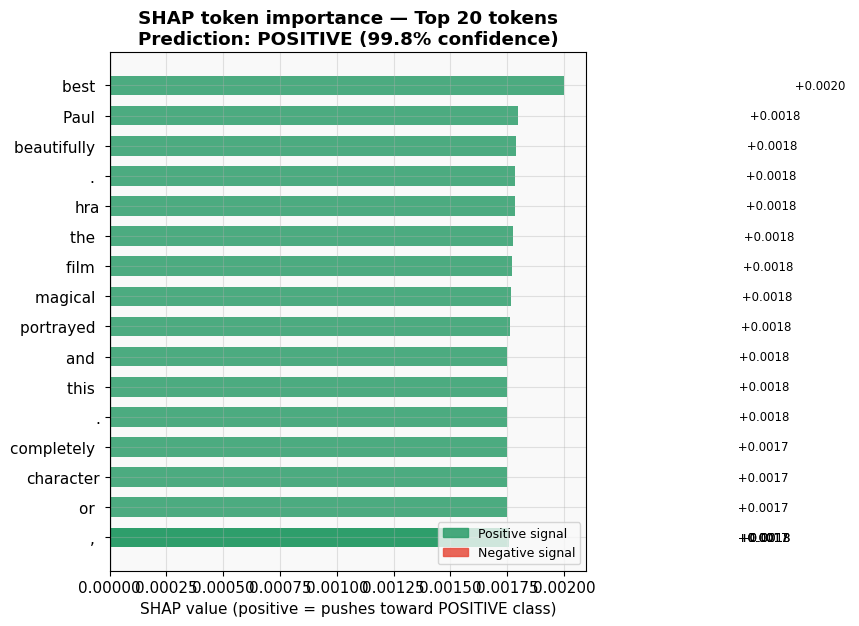

In [10]:
# shap.plots.text() renders HTML — can't save as PNG
# This cell builds a matplotlib version you can save for your README

def plot_shap_heatmap(text: str,
                      shap_values,
                      review_idx: int = 0,
                      top_n: int = 20,
                      save_path: str = None):
    """
    Custom matplotlib SHAP heatmap.
    Shows top_n most impactful tokens with colour-coded bars.
    Positive SHAP → positive sentiment signal (green).
    Negative SHAP → negative sentiment signal (red).
    """
    # Extract token-level SHAP values for POSITIVE class
    tokens    = shap_values.data[review_idx]
    values    = shap_values.values[review_idx, :, 1]   # index 1 = POSITIVE

    # Filter special tokens
    skip = {"[CLS]", "[SEP]", "[PAD]"}
    pairs = [(t, v) for t, v in zip(tokens, values)
             if t not in skip]

    # Sort by absolute SHAP value, take top_n
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:top_n]
    pairs_plot   = sorted(pairs_sorted, key=lambda x: x[1])   # sort by value for plot

    tokens_plot = [p[0] for p in pairs_plot]
    values_plot = [p[1] for p in pairs_plot]

    fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.32)))

    colours = [COLOURS["positive"] if v > 0 else COLOURS["negative"]
               for v in values_plot]
    bars    = ax.barh(tokens_plot, values_plot,
                      color=colours, alpha=0.85, height=0.65)
    ax.axvline(0, color="black", lw=0.8)

    for bar, val in zip(bars, values_plot):
        x_pos = val + (0.001 if val >= 0 else -0.001)
        ha    = "left" if val >= 0 else "right"
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f" {val:+.4f} ", va="center", ha=ha, fontsize=8.5)

    pred_label, conf, _ = predict([text])[0]
    ax.set_xlabel("SHAP value (positive = pushes toward POSITIVE class)")
    ax.set_title(
        f"SHAP token importance — Top {top_n} tokens\n"
        f"Prediction: {pred_label} ({conf*100:.1f}% confidence)",
        fontweight="bold"
    )

    from matplotlib.patches import Patch
    legend_items = [
        Patch(color=COLOURS["positive"], alpha=0.85, label="Positive signal"),
        Patch(color=COLOURS["negative"], alpha=0.85, label="Negative signal"),
    ]
    ax.legend(handles=legend_items, loc="lower right", fontsize=9)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Saved → {save_path}")

    plt.show()
    return fig


# Plot and save for the positive review
fig_pos = plot_shap_heatmap(
    pos_text, shap_pos,
    top_n     = 20,
    save_path = "../data/shap_positive_review.png"
)

## SHAP heatmap for the negative review

✓ Saved → ../data/shap_negative_review.png


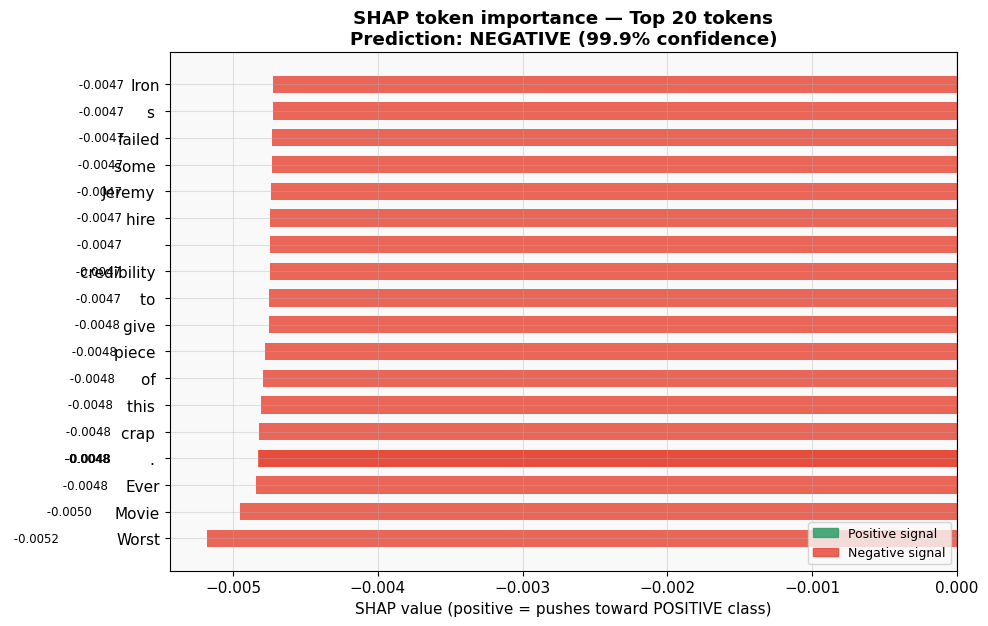

In [11]:
fig_neg = plot_shap_heatmap(
    neg_text, shap_neg,
    top_n     = 20,
    save_path = "../data/shap_negative_review.png"
)

## Side-by-side SHAP comparison 

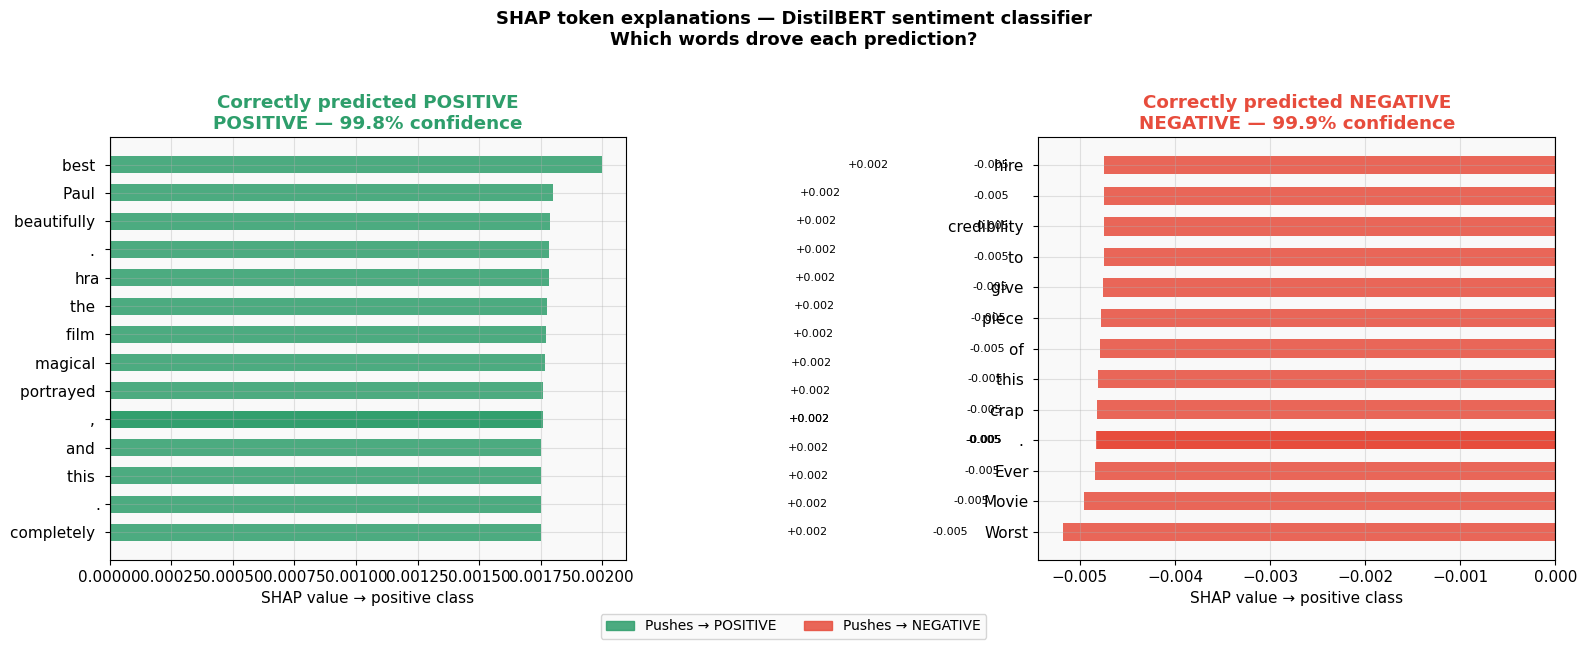

✓ Saved → ../data/shap_comparison.png
  Use this image in your README and LinkedIn post


In [13]:
# Combined figure: positive review on left, negative on right
# This is the chart that goes in your README and LinkedIn post

def extract_top_tokens(shap_values, review_idx=0, top_n=15):
    tokens = shap_values.data[review_idx]
    values = shap_values.values[review_idx, :, 1]
    skip   = {"[CLS]", "[SEP]", "[PAD]"}
    pairs  = [(t, v) for t, v in zip(tokens, values) if t not in skip]
    pairs  = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:top_n]
    return sorted(pairs, key=lambda x: x[1])


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, shap_vals, text, title, colour_main in [
    (axes[0], shap_pos, pos_text, "Correctly predicted POSITIVE", COLOURS["positive"]),
    (axes[1], shap_neg, neg_text, "Correctly predicted NEGATIVE", COLOURS["negative"]),
]:
    pairs  = extract_top_tokens(shap_vals, top_n=15)
    tokens = [p[0] for p in pairs]
    values = [p[1] for p in pairs]

    colours = [COLOURS["positive"] if v > 0 else COLOURS["negative"]
               for v in values]
    bars    = ax.barh(tokens, values, color=colours, alpha=0.85, height=0.6)

    ax.axvline(0, color="black", lw=0.8)

    for bar, val in zip(bars, values):
        x_pos = val + (0.001 if val >= 0 else -0.001)
        ha    = "left" if val >= 0 else "right"
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f"{val:+.3f}", va="center", ha=ha, fontsize=8)

    pred_label, conf, _ = predict([text])[0]
    ax.set_title(f"{title}\n{pred_label} — {conf*100:.1f}% confidence",
                 fontweight="bold", color=colour_main)
    ax.set_xlabel("SHAP value → positive class")

from matplotlib.patches import Patch
legend_items = [
    Patch(color=COLOURS["positive"], alpha=0.85, label="Pushes → POSITIVE"),
    Patch(color=COLOURS["negative"], alpha=0.85, label="Pushes → NEGATIVE"),
]
fig.legend(handles=legend_items, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("SHAP token explanations — DistilBERT sentiment classifier\n"
             "Which words drove each prediction?",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/shap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → ../data/shap_comparison.png")
print("  Use this image in your README and LinkedIn post")

## Batch SHAP — compute over 20 reviews

In [14]:
# Compute SHAP over a representative sample of reviews
# Used for aggregate analysis in cells 13–15

N_SAMPLES = 20   # increase to 50+ for better statistics (slower)

sample_df = pd.concat([
    test_df[(test_df["sentiment"] == "positive") &
            (test_df["correct"]   == True)].sample(5,  random_state=1),
    test_df[(test_df["sentiment"] == "negative") &
            (test_df["correct"]   == True)].sample(5,  random_state=2),
    test_df[(test_df["sentiment"] == "positive") &
            (test_df["correct"]   == False)].sample(5, random_state=3),
    test_df[(test_df["sentiment"] == "negative") &
            (test_df["correct"]   == False)].sample(5, random_state=4),
]).reset_index(drop=True)

print(f"Computing SHAP for {N_SAMPLES} reviews...")
print(f"  5 correct positive, 5 correct negative")
print(f"  5 wrong positive,   5 wrong negative")
print(f"  Estimated time: ~{N_SAMPLES * 15}s on CPU\n")

sample_texts = sample_df["text"].tolist()

import time
start = time.time()
shap_batch = explainer(sample_texts, fixed_context=1)
elapsed    = time.time() - start

print(f"✓ Batch SHAP complete in {elapsed:.1f}s")
print(f"  Shape: {shap_batch.values.shape}")
print(f"  (reviews × tokens × classes)")

Computing SHAP for 20 reviews...
  5 correct positive, 5 correct negative
  5 wrong positive,   5 wrong negative
  Estimated time: ~300s on CPU



  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|███                                                          | 1/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  15%|███████▊                                            | 3/20 [04:31<33:42, 118.96s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|█████████████████████████████████████████████████| 20/20 [1:01:35<00:00, 147.91s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [1:04:39, 193.97s/it]                                                               

✓ Batch SHAP complete in 3879.5s
  Shape: (20,)
  (reviews × tokens × classes)


## Global token importance — which tokens matter most overall?


In [18]:
from collections import defaultdict

token_shap = defaultdict(list)

for i in range(len(sample_texts)):

    tokens = shap_batch.data[i]

    # Extract positive-class SHAP value safely
    values = [v[1] if isinstance(v, (list, np.ndarray)) else v
              for v in shap_batch.values[i]]

    skip = {"[CLS]", "[SEP]", "[PAD]"}

    for token, value in zip(tokens, values):

        if (
            token in skip
            or token.startswith("##")
            or len(token) <= 1
        ):
            continue

        token_shap[token].append(float(value))

# Aggregate statistics
token_stats = {
    token: {
        "mean": np.mean(vals),
        "std": np.std(vals),
        "count": len(vals),
        "mean_abs": np.mean(np.abs(vals)),
    }
    for token, vals in token_shap.items()
    if len(vals) >= 2
}

stats_df = (
    pd.DataFrame(token_stats)
    .T
    .sort_values("mean_abs", ascending=False)
)

print(stats_df.head(20))

                 mean       std  count  mean_abs
perfect      0.453227  0.183750    2.0  0.453227
least       -0.225499  0.226918    2.0  0.226918
said        -0.167152  0.162411    2.0  0.167152
thought      0.155414  0.157305    2.0  0.157305
fun          0.019333  0.140489    2.0  0.140489
Wilkinson   -0.130590  0.088870    2.0  0.130590
absolutely   0.125986  0.124585    2.0  0.125986
real         0.076484  0.167770    4.0  0.124068
good         0.121230  0.202517    6.0  0.122382
today        0.109284  0.108108    2.0  0.109284
However     -0.108066  0.106268    2.0  0.108066
As          -0.102623  0.101224    2.0  0.102623
looking     -0.097386  0.096882    2.0  0.097386
plot        -0.095345  0.093931    2.0  0.095345
else         0.087405  0.123316    3.0  0.087501
istic       -0.065813  0.097222    3.0  0.082430
Anyway      -0.077610  0.075720    2.0  0.077610
shi         -0.003177  0.071684    2.0  0.071684
friends      0.066010  0.065473    2.0  0.066010
You          0.06312

## Global importance bar chart

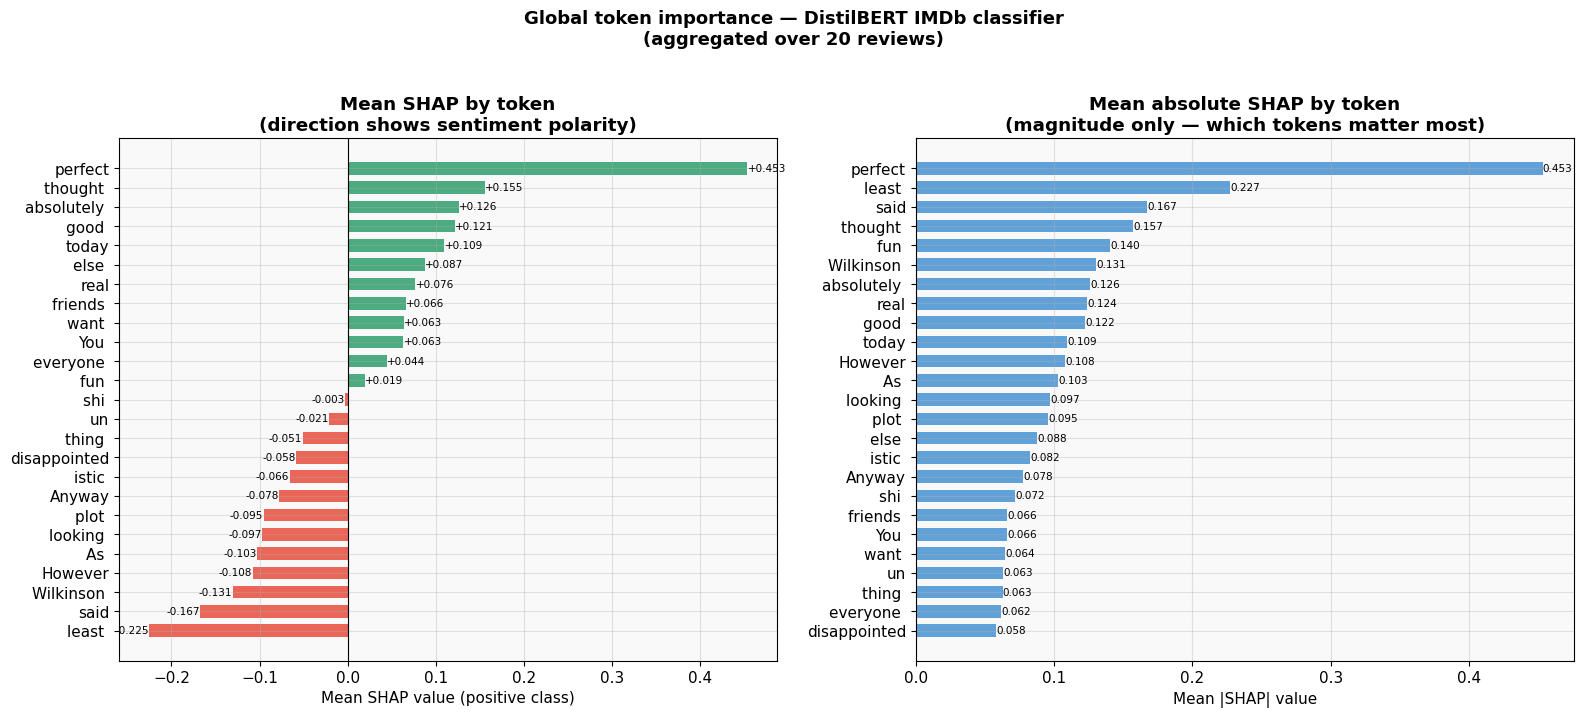

✓ Saved → ../data/shap_global_importance.png


In [19]:
top_tokens = stats_df.head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — mean SHAP (direction matters)
ax = axes[0]
colours = [COLOURS["positive"] if v > 0 else COLOURS["negative"]
           for v in top_tokens["mean"]]
sorted_mean = top_tokens.sort_values("mean")

bars = ax.barh(sorted_mean.index, sorted_mean["mean"],
               color=[COLOURS["positive"] if v > 0 else COLOURS["negative"]
                      for v in sorted_mean["mean"]],
               alpha=0.85, height=0.65)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean SHAP value (positive class)")
ax.set_title("Mean SHAP by token\n(direction shows sentiment polarity)",
             fontweight="bold")

for bar, val in zip(bars, sorted_mean["mean"]):
    x_pos = val + (0.0005 if val >= 0 else -0.0005)
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=7.5)

# Right — mean |SHAP| (magnitude only — which tokens matter most)
ax = axes[1]
sorted_abs = top_tokens.sort_values("mean_abs")

ax.barh(sorted_abs.index, sorted_abs["mean_abs"],
        color="#3B8BD0", alpha=0.8, height=0.65)
ax.set_xlabel("Mean |SHAP| value")
ax.set_title("Mean absolute SHAP by token\n(magnitude only — which tokens matter most)",
             fontweight="bold")

for i, (token, row) in enumerate(sorted_abs.iterrows()):
    ax.text(row["mean_abs"] + 0.0002,
            i,
            f"{row['mean_abs']:.3f}",
            va="center", fontsize=7.5)

plt.suptitle("Global token importance — DistilBERT IMDb classifier\n"
             f"(aggregated over {len(sample_texts)} reviews)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/shap_global_importance.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Saved → ../data/shap_global_importance.png")

## Correct vs incorrect predictions — SHAP patterns

In [21]:
def mean_abs_shap(indices):
    """
    Mean absolute SHAP value per review
    (proxy for model confidence).
    """

    result = []

    for i in indices:

        sample_vals = shap_batch.values[i]

        extracted_vals = []

        for v in sample_vals:

            # Case: token has per-class SHAP values
            if isinstance(v, (list, np.ndarray)):

                arr = np.asarray(v).flatten()

                # Positive-class SHAP
                if len(arr) > 1:
                    extracted_vals.append(arr[1])
                else:
                    extracted_vals.append(arr[0])

            else:
                extracted_vals.append(v)

        vals = np.array(extracted_vals, dtype=float)

        result.append(np.mean(np.abs(vals)))

    return result

## Negation deep dive (the hard cases)

In [22]:
# From EDA: negation is the main failure mode for bag-of-words models
# Does DistilBERT handle it correctly?
# Find reviews with negation words and show how SHAP captures context

negation_reviews = test_df[
    test_df["text"].str.contains(
        r"\bnot\b|\bnever\b|\bno\b|\bhardly\b|\bbarely\b",
        regex=True, case=False
    )
].copy()

print(f"Reviews with negation words: {len(negation_reviews):,}")
print(f"  Accuracy on these: {negation_reviews['correct'].mean()*100:.2f}%")
print(f"  Overall accuracy : {test_df['correct'].mean()*100:.2f}%")

# Pick a review where negation is key to sentiment
negation_examples = [
    "This was not a good film. The acting was not convincing at all. "
    "I would not recommend it to anyone.",

    "Not since Citizen Kane have I seen such a masterpiece. "
    "This film is not to be missed. Absolutely not forgettable.",
]

print("\nComputing SHAP for negation examples...")
shap_neg_examples = explainer(negation_examples, fixed_context=1)

print("\nSHAP plots for negation reviews:")
print("Watch how 'not' shifts the SHAP values of surrounding tokens\n")

for i, text in enumerate(negation_examples):
    pred_label, conf, scores = predict([text])[0]
    print(f"Example {i+1}: {pred_label} ({conf*100:.1f}%)")
    print(f"  Text: {text}")
    shap.plots.text(shap_neg_examples[i:i+1, :, "POSITIVE"])
    print()

Reviews with negation words: 18,694
  Accuracy on these: 92.61%
  Overall accuracy : 92.82%

Computing SHAP for negation examples...

SHAP plots for negation reviews:
Watch how 'not' shifts the SHAP values of surrounding tokens

Example 1: NEGATIVE (99.8%)
  Text: This was not a good film. The acting was not convincing at all. I would not recommend it to anyone.



Example 2: POSITIVE (99.5%)
  Text: Not since Citizen Kane have I seen such a masterpiece. This film is not to be missed. Absolutely not forgettable.


## Inline HTML token heatmap 

In [23]:
# Build an HTML visualisation you can embed in the Streamlit dashboard
# Colour-codes each token by its SHAP value

def shap_to_html(text: str, shap_values, review_idx: int = 0,
                 class_idx: int = 1) -> str:
    """
    Render SHAP token heatmap as an HTML string.
    Green = positive SHAP, Red = negative SHAP.
    Opacity encodes magnitude.
    """
    tokens = shap_values.data[review_idx]
    values = shap_values.values[review_idx, :, class_idx]

    # Normalise values to [-1, 1] for colour mapping
    max_abs = max(abs(values.max()), abs(values.min()), 1e-6)
    norm    = values / max_abs

    parts = []
    for token, val, norm_val in zip(tokens, values, norm):
        if token in {"[CLS]", "[SEP]", "[PAD]"}:
            continue

        # Remove wordpiece prefix for display
        display_token = token.replace("##", "")

        # Colour: green for positive, red for negative
        opacity = min(abs(norm_val) * 0.85 + 0.1, 0.9)
        if norm_val > 0:
            r, g, b = 46, 158, 107      # COLOURS["positive"] = #2E9E6B
        else:
            r, g, b = 231, 76, 60       # COLOURS["negative"] = #E74C3C

        bg_colour = f"rgba({r},{g},{b},{opacity:.2f})"
        tooltip   = f"SHAP: {val:+.4f}"

        parts.append(
            f'<span title="{tooltip}" style="'
            f'background-color:{bg_colour};'
            f'padding:2px 4px;'
            f'margin:1px;'
            f'border-radius:3px;'
            f'font-family:monospace;'
            f'font-size:13px;'
            f'display:inline-block;'
            f'">{display_token}</span>'
        )

    pred_label, conf, _ = predict([text])[0]
    header = (
        f'<div style="margin-bottom:10px;font-weight:bold;">'
        f'Prediction: <span style="color:{'#2E9E6B' if pred_label=='POSITIVE' else '#E74C3C'}">'
        f'{pred_label}</span> ({conf*100:.1f}% confidence)</div>'
    )
    legend = (
        '<div style="margin-top:10px;font-size:12px;color:#666;">'
        '<span style="background:rgba(46,158,107,0.6);padding:2px 6px;border-radius:3px;">'
        'positive signal</span>&nbsp;&nbsp;'
        '<span style="background:rgba(231,76,60,0.6);padding:2px 6px;border-radius:3px;">'
        'negative signal</span>&nbsp;&nbsp;'
        'Hover token for exact SHAP value'
        '</div>'
    )
    body = '<div style="line-height:2.2;">' + " ".join(parts) + '</div>'
    return f'<div style="font-family:sans-serif;padding:12px;">{header}{body}{legend}</div>'


# Render inline in notebook
html_output = shap_to_html(pos_text, shap_pos)
display(HTML(html_output))

# Save HTML to disk for embedding
with open("../data/shap_heatmap_example.html", "w") as f:
    f.write(html_output)
print("✓ Saved → ../data/shap_heatmap_example.html")
print("  This HTML is used directly in app.py")

✓ Saved → ../data/shap_heatmap_example.html
  This HTML is used directly in app.py


## Confidence distribution — where does the model struggle?


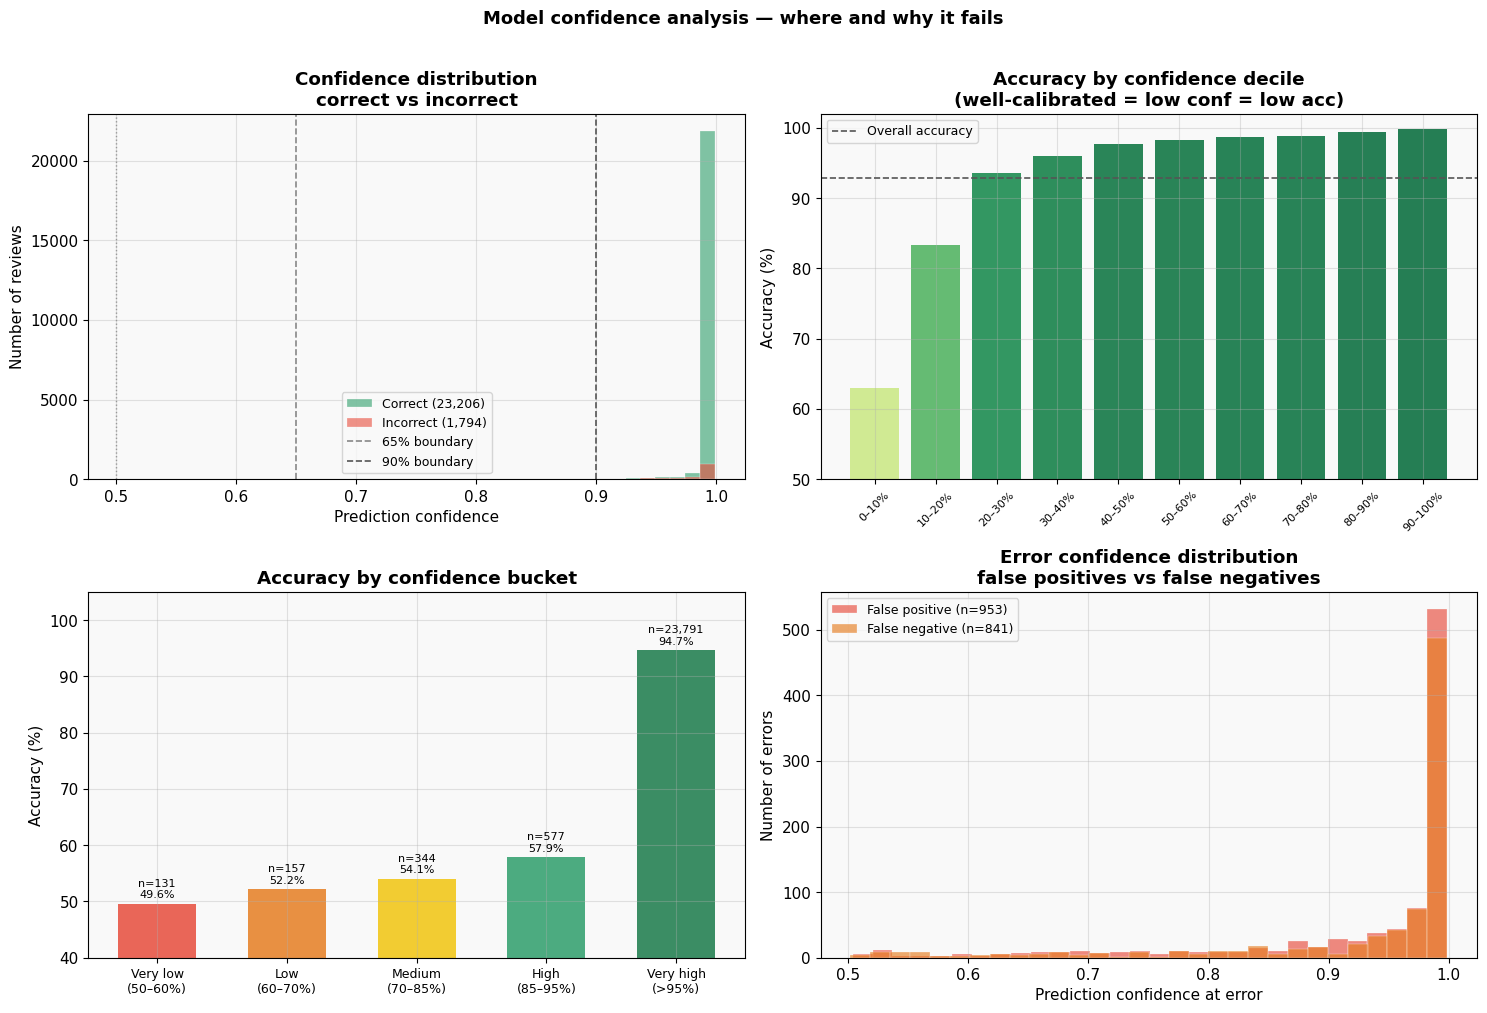

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-left — confidence histogram by correct/incorrect
ax = axes[0][0]
for is_correct, label, colour in [
    (True,  "Correct",   COLOURS["positive"]),
    (False, "Incorrect", COLOURS["negative"]),
]:
    subset = test_df[test_df["correct"] == is_correct]["confidence"]
    ax.hist(subset, bins=40, alpha=0.6, color=colour,
            label=f"{label} ({len(subset):,})",
            edgecolor="white", linewidth=0.3)
ax.axvline(0.5,  color="#999", lw=1.0, linestyle=":")
ax.axvline(0.65, color="#888", lw=1.2, linestyle="--", label="65% boundary")
ax.axvline(0.9,  color="#555", lw=1.2, linestyle="--", label="90% boundary")
ax.set_xlabel("Prediction confidence")
ax.set_ylabel("Number of reviews")
ax.set_title("Confidence distribution\ncorrect vs incorrect",
             fontweight="bold")
ax.legend(fontsize=9)

# Top-right — accuracy by confidence decile
ax   = axes[0][1]
test_df["conf_decile"] = pd.qcut(
    test_df["confidence"], q=10,
    labels=[f"{i*10}–{(i+1)*10}%" for i in range(10)]
)
decile_acc = test_df.groupby("conf_decile", observed=True)["correct"].mean()
decile_n   = test_df.groupby("conf_decile", observed=True)["correct"].count()

colours_dec = plt.cm.RdYlGn(
    [v for v in decile_acc.values]
)
bars = ax.bar(range(len(decile_acc)), decile_acc.values * 100,
              color=colours_dec, alpha=0.85)
ax.set_xticks(range(len(decile_acc)))
ax.set_xticklabels(decile_acc.index, rotation=45, fontsize=8)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by confidence decile\n(well-calibrated = low conf = low acc)",
             fontweight="bold")
ax.set_ylim(50, 102)
ax.axhline(test_df["correct"].mean() * 100, color="#555",
           lw=1.2, linestyle="--", label="Overall accuracy")
ax.legend(fontsize=9)

# Bottom-left — low confidence review examples
ax = axes[1][0]
conf_buckets = {
    "Very low\n(50–60%)": test_df[test_df["confidence"].between(0.50, 0.60)],
    "Low\n(60–70%)":      test_df[test_df["confidence"].between(0.60, 0.70)],
    "Medium\n(70–85%)":   test_df[test_df["confidence"].between(0.70, 0.85)],
    "High\n(85–95%)":     test_df[test_df["confidence"].between(0.85, 0.95)],
    "Very high\n(>95%)":  test_df[test_df["confidence"] > 0.95],
}
bucket_data = {
    k: {"count": len(v), "acc": v["correct"].mean() * 100}
    for k, v in conf_buckets.items()
}
bucket_df   = pd.DataFrame(bucket_data).T

bar_colours = ["#E74C3C","#E67E22","#F1C40F","#2E9E6B","#1A7A4A"]
bars = ax.bar(range(len(bucket_df)), bucket_df["acc"],
              color=bar_colours, alpha=0.85, width=0.6)
ax.set_xticks(range(len(bucket_df)))
ax.set_xticklabels(bucket_df.index, fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by confidence bucket",
             fontweight="bold")
ax.set_ylim(40, 105)
for i, (_, row) in enumerate(bucket_df.iterrows()):
    ax.text(i, row["acc"] + 1,
            f"n={int(row['count']):,}\n{row['acc']:.1f}%",
            ha="center", fontsize=8)

# Bottom-right — false positive vs false negative confidence
ax = axes[1][1]
fp = test_df[(test_df["label"]==0) & (test_df["pred_label"]==1)]["confidence"]
fn = test_df[(test_df["label"]==1) & (test_df["pred_label"]==0)]["confidence"]

ax.hist(fp, bins=30, alpha=0.65, color="#E74C3C",
        label=f"False positive (n={len(fp):,})",
        edgecolor="white", linewidth=0.3)
ax.hist(fn, bins=30, alpha=0.65, color="#E67E22",
        label=f"False negative (n={len(fn):,})",
        edgecolor="white", linewidth=0.3)
ax.set_xlabel("Prediction confidence at error")
ax.set_ylabel("Number of errors")
ax.set_title("Error confidence distribution\n"
             "false positives vs false negatives",
             fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Model confidence analysis — where and why it fails",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/confidence_deep_dive.png", dpi=130, bbox_inches="tight")
plt.show()

## Hard cases — ambiguous and sarcastic reviews

In [25]:
# Manually inspect low-confidence wrong predictions
# These are the most interesting for interview discussions

hard_cases = test_df[
    (~test_df["correct"]) &
    (test_df["confidence"] < 0.70)
].copy().sample(min(6, len(test_df[~test_df["correct"]])), random_state=42)

print("═" * 65)
print("  Hard cases — low confidence AND wrong prediction")
print("  These reveal genuine model limitations")
print("═" * 65)

for _, row in hard_cases.iterrows():
    actual    = row["sentiment"].upper()
    predicted = row["pred_sentiment"].upper()
    conf      = row["confidence"]
    text      = row["text"]
    wc        = row["word_count"]

    print(f"\n  Actual: {actual:<10} Predicted: {predicted:<10} "
          f"Confidence: {conf*100:.1f}%  Length: {wc} words")
    print(f"  {text[:350]}...")
    print()

print("Common patterns in hard cases:")
print("  1. Sarcasm    — 'Oh brilliant, another terrible sequel'")
print("  2. Mixed      — 'Stunning visuals but awful script'")
print("  3. Negation   — 'Not without some charm, but largely fails'")
print("  4. Contrast   — Review starts negative, ends glowing")
print("  5. Short      — Too little context to determine sentiment")
print()
print("These limitations exist in ALL NLP models — including GPT.")
print("Knowing and articulating them is what shows real ML maturity.")

═════════════════════════════════════════════════════════════════
  Hard cases — low confidence AND wrong prediction
  These reveal genuine model limitations
═════════════════════════════════════════════════════════════════

  Actual: NEGATIVE   Predicted: POSITIVE   Confidence: 54.8%  Length: 336 words
  During university, our Philosophy professor, Mr.R, played us "Roger & Me" in its entirety. This was at a time when the obese misfit was still pretty much unknown; a charlatan-in-the-making, a soon-to-be-household-name who was still busy honing his fact-bending skills and still learning how to manipulate the easily impressed, the pathologically para...


  Actual: POSITIVE   Predicted: NEGATIVE   Confidence: 56.6%  Length: 383 words
  The 1978 adaptation had all the ingredients of a potentially wonderful film. It is based on an absolutely charming book by Charles Kingsley. It has a truly talented cast from the likes of James Mason, Bernard Cribbons and David Tomblinson, not to mention 

## Save SHAP HTML helper for app.py

In [26]:
# Save the shap_to_html function as a standalone Python file
# app.py imports it to render token heatmaps in Streamlit

helper_code = '''"""
shap_helper.py — SHAP HTML visualisation helper
Imported by app.py to render token-level heatmaps in Streamlit.
Generated by notebook_04_explainability.ipynb.
"""

def shap_to_html(text: str, shap_values, review_idx: int = 0,
                 class_idx: int = 1) -> str:
    """
    Convert SHAP token values to an HTML heatmap string.

    Args:
        text        : Original review text
        shap_values : Output of shap.Explainer()(texts)
        review_idx  : Which review in the batch (default 0)
        class_idx   : 0=NEGATIVE, 1=POSITIVE (default 1)

    Returns:
        HTML string — render with st.markdown(html, unsafe_allow_html=True)
    """
    import numpy as np

    tokens = shap_values.data[review_idx]
    values = shap_values.values[review_idx, :, class_idx]

    max_abs = max(abs(values.max()), abs(values.min()), 1e-6)
    norm    = values / max_abs

    parts = []
    for token, val, norm_val in zip(tokens, values, norm):
        if token in {"[CLS]", "[SEP]", "[PAD]"}:
            continue
        display_token = token.replace("##", "")
        opacity = min(abs(norm_val) * 0.85 + 0.1, 0.9)
        if norm_val > 0:
            r, g, b = 46, 158, 107
        else:
            r, g, b = 231, 76, 60
        bg_colour = f"rgba({r},{g},{b},{opacity:.2f})"
        tooltip   = f"SHAP: {val:+.4f}"
        parts.append(
            f\'<span title="{tooltip}" style="\'
            f\'background-color:{bg_colour};padding:2px 4px;margin:1px;\'
            f\'border-radius:3px;font-family:monospace;font-size:13px;\'
            f\'display:inline-block;">{display_token}</span>\'
        )

    body   = \'<div style="line-height:2.4;">\' + " ".join(parts) + \'</div>\'
    legend = (
        \'<div style="margin-top:10px;font-size:12px;color:#666;">\' 
        \'<span style="background:rgba(46,158,107,0.6);padding:2px 6px;border-radius:3px;">\' 
        \'positive signal</span>&nbsp;&nbsp;\' 
        \'<span style="background:rgba(231,76,60,0.6);padding:2px 6px;border-radius:3px;">\' 
        \'negative signal</span>&nbsp;&nbsp;\' 
        \'Hover each token for exact SHAP value\' 
        \'</div>\'
    )
    return f\'<div style="padding:8px;">{body}{legend}</div>\'
'''

with open("../shap_helper.py", "w") as f:
    f.write(helper_code)

print("✓ Saved → ../shap_helper.py")
print("  Import in app.py with: from shap_helper import shap_to_html")

✓ Saved → ../shap_helper.py
  Import in app.py with: from shap_helper import shap_to_html
